<a href="https://colab.research.google.com/github/ochilovu2010/IOAI/blob/main/NitroAI/3_problem_Slovak_OAI_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
#https://judge.nitro-ai.org/competitions/slovenska-olympiada/slovak-aoi-2026/3/view
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

In [49]:
!unzip "/content/train_data.zip" -d "/content/train"

Archive:  /content/train_data.zip
replace /content/train/0000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [50]:
!unzip '/content/starter.zip' -d '/content/sample/'

Archive:  /content/starter.zip
replace /content/sample/anomaly.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [51]:
sample = pd.read_csv('/content/sample.csv')


cuda:0
torch.Size([1, 1, 28, 28])


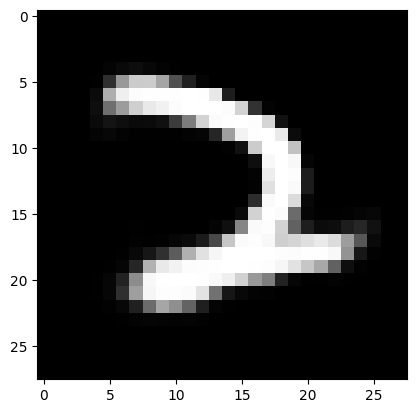

In [52]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

# load variational autoencoder
encoder = torch.load('/content/sample/mnist_cvae8_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('/content/sample/mnist_cvae8_decoder.pth', weights_only=False, map_location=device)
encoder.eval()
decoder.eval()

# binarize
def binarize(x):
    return (x > 0.5).float()

# run autocoder
def autoencoder(x, latent_dim=8):
    return decoder(encoder(x)[:,:latent_dim])

# Load image
directory = "/content/train/"
i=99
transform = transforms.ToTensor()
img = transform(Image.open(f"{directory}/{i:04d}.png"))

# Process image
batch = img.unsqueeze(0).to(device)
print(batch.shape)
with torch.no_grad():
    result = autoencoder(batch)
# Display result
plt.imshow((result.squeeze(0).squeeze(0).cpu().numpy()*255).astype(np.uint8),cmap='gray')
plt.show()


In [53]:
class imagedataset(Dataset):
  def __init__(self, img_dir):
    self.main_dir = img_dir
    self.length = 10000
  def __len__(self):
    return self.length
  def __getitem__(self, x):
    img_path = os.path.join(self.main_dir, f"{x:04d}.png")
    img = transforms.ToTensor()(Image.open(img_path))
    return img

In [54]:
data = imagedataset('/content/train')
loader = DataLoader(data, batch_size = 32)

In [55]:
reconstruction_error = torch.tensor([])
for x in loader:
  with torch.no_grad():
    result = autoencoder(x.to(device))
  mse_per_pixel = F.mse_loss(x, result.cpu(), reduction='none')
  mse_per_image = mse_per_pixel.view(x.size(0), -1).mean(dim=1)
  reconstruction_error = torch.cat([reconstruction_error, mse_per_image], dim=0)

(array([ 1.,  4.,  1.,  1.,  3.,  7.,  8., 20., 19., 16., 19., 27., 26.,
        29., 29., 39., 29., 41., 33., 38., 28., 40., 32., 43., 43., 28.,
        32., 28., 31., 27., 27., 29., 27., 27., 30., 32., 34., 40., 37.,
        35., 36., 41., 43., 29., 46., 45., 46., 48., 46., 43., 45., 58.,
        45., 43., 52., 54., 62., 75., 70., 51., 80., 62., 69., 76., 80.,
        79., 76., 68., 78., 91., 79., 58., 83., 76., 89., 81., 78., 84.,
        93., 85., 83., 73., 87., 85., 83., 73., 74., 78., 70., 83., 82.,
        75., 70., 58., 69., 64., 83., 81., 76., 72., 62., 73., 60., 64.,
        67., 51., 59., 61., 53., 54., 59., 70., 54., 50., 67., 48., 57.,
        39., 54., 52., 61., 49., 47., 48., 59., 50., 39., 43., 36., 37.,
        30., 40., 27., 34., 39., 40., 31., 26., 29., 28., 27., 31., 31.,
        35., 22., 35., 24., 25., 24., 31., 20., 19., 20., 28., 20., 33.,
        29., 20., 25., 24., 18., 15., 22., 24., 18., 19., 17., 18., 12.,
        14., 10., 17., 12., 16., 14., 12., 15., 10.

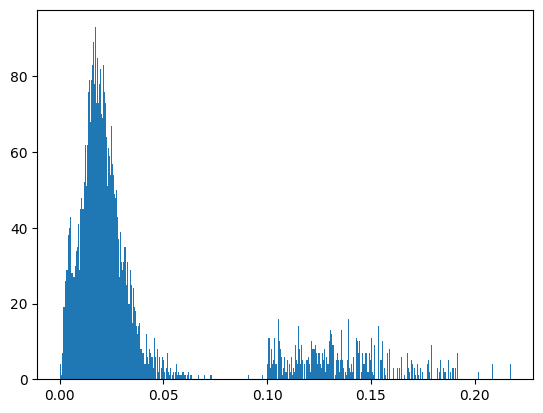

In [56]:
plt.hist(reconstruction_error, bins=1000)

In [57]:
letters = [chr(i) for i in range(ord('A'), ord('Z')+1)]
examples = {l: [] for l in letters}
examples['A'] = [351, 5]
examples['B'] = [276, 101]
examples['C'] = [0, 9, 140]
examples['D'] = [327, 168, 56, 77]
examples['E'] = [322, 32, 62]
examples['F'] = [383, 314, 279, 91, 106]
examples['G'] = [285, ]
examples['H'] = [319, 291, 55, 61, 96]
examples['I'] = []
examples['J'] = []
examples['K'] = [54]
examples['L'] = [136]
examples['M'] = [339, 310, 313, 176, 115]
examples['N'] = [44, 79, 89]
examples['P'] = [366, 38, 190]
examples['Q'] = [360, 237, 232]
examples['R'] = [359, 316, 235, 157, 123, 14, 18, 31, 39]
examples['S'] = [249, 182, 92]
examples['T'] = []
examples['U'] = [288, 110]
examples['V'] = [281, 207, 224]
examples['W'] = [378, 3, 124, 126, 148]
examples['X'] = [231, 97, 138]
examples['Y'] = [253, 8, 217]
examples['Z'] = [329,]

In [58]:
def assign_letter(error):
    best, diff = 'A', 1.0
    for k, v in examples.items():
        for i in v:
            if abs(errors[i] - error) < diff:
                diff = abs(errors[i] - error)
                best = k
    return best

In [59]:
errors = reconstruction_error
thresh = 0.075
indices = np.where(errors.cpu().numpy() > thresh)[0]
count = len(indices)
num_binary = count

percentage = round(100*(num_binary / 10000), 2)
reconstruction_error = round(max(errors).item(), 5)
letters = ''.join([assign_letter(errors[i]) for i in indices])

rows = []

rows.append([1, 0, round(percentage,2)])

rows.append([2, 0, round(reconstruction_error,5)])

categories = [0]*10000
for index in indices:
    categories[index] = 1
for i, category in enumerate(categories):
    rows.append([3, i, category])

rows.append([4, 0, count])

characters = [' ']*10000
for index, letter in zip(indices, letters):
    characters[index] = letter
for i, character in enumerate(characters):
    rows.append([5, i, character])

df = pd.DataFrame(rows, columns=["subtaskID", "datapointID", "answer"])
df.to_csv("submission.csv", index=False, header=True)